# Transfer Learning with Vision-Language Models for Image Classification

## 🎯 Learning Objectives  

By the end of this notebook, you will:  
- Learn how to adapt CLIP to downstream classification tasks;  
- Apply **PEFT** (Parameter-Efficient Fine-Tuning) techniques for efficient fine-tuning;
- We apply Transfer Learning for Image Classification using the Oxford Pets dataset.

In [ ]:
# Install required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers pillow requests matplotlib seaborn ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

In [2]:
# Import libraries
import warnings
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import clip
import wandb

from PIL import Image
from tqdm import tqdm
from datasets import load_dataset

warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

/nfs/home/dasaro/ADSP/2025-26/L19/.venv/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/nfs/home/dasaro/ADSP/2025-26/L19/.venv/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have ha

#### The OxfordPets dataset
Contents:
- 37 categories of pet breeds — cats and dogs
- Each image has a class label (breed)
- Around 200 images per class, totaling about 7,400 images

<!-- ![alt text](image.png) -->

In [3]:
class OxfordPetsDataset:
  def __init__(self):
    self.dataset_name = "oxford_pets"
    self.dataset = load_dataset("timm/oxford-iiit-pet")
    self.classnames = [
        'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau',
        'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx',
        'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle',
        'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter',
        'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin',
        'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian',
        'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu',
        'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier'
    ]

class CustomDataLoader:
  def __init__(self, dataset, split, preprocess, batch_size=32):
    try:
      self.dataset = dataset[split]
    except AttributeError:
      raise ValueError(f"Invalid dataset: {dataset}")

    self.preprocess = preprocess
    self.batch_size = batch_size

  def __len__(self):
    return len(self.dataset) // self.batch_size + (1 if len(self.dataset) % self.batch_size > 0 else 0)

  def __iter__(self):
    for i in range(0, len(self.dataset), self.batch_size):
      batch = self.dataset[i:i+self.batch_size]

      images = []
      labels = []

      for image in batch['image']:
        if not isinstance(image, Image.Image):
          image = Image.fromarray(image)
        processed_image = self.preprocess(image)
        images.append(processed_image)

      labels = batch['label']

      images = torch.stack(images)
      labels = torch.tensor(labels)

      yield images, labels

#### Zero-Shot Classification in CLIP with Prompt Ensembling

- CLIP performs zero-shot classification by comparing image embeddings with text embeddings of class descriptions.
- Instead of a single prompt, multiple textual prompts are used to represent each class (e.g., "a photo of a cat", "an image of a cat", "a picture of a cat").
- Each prompt is encoded by the text encoder to produce prompt embeddings.
- The mean of these embeddings forms the final class embedding.
- This process is repeated for all classes, enabling robust and context-aware classification without additional training.

In [4]:
# Handcrafted prompt templates from the original CLIP paper, used for zero-shot classification through prompt ensembling
PROMPTS = [
      'a bad photo of a {}.', 'a photo of many {}.', 'a sculpture of a {}.', 'a photo of the hard to see {}.', 'a low resolution photo of the {}.', 'a rendering of a {}.',
      'graffiti of a {}.', 'a bad photo of the {}.', 'a cropped photo of the {}.', 'a tattoo of a {}.', 'the embroidered {}.', 'a photo of a hard to see {}.',
      'a bright photo of a {}.', 'a photo of a clean {}.', 'a photo of a dirty {}.', 'a dark photo of the {}.', 'a drawing of a {}.', 'a photo of my {}.',
      'the plastic {}.', 'a photo of the cool {}.', 'a close-up photo of a {}.', 'a black and white photo of the {}.',
      'a painting of the {}.', 'a painting of a {}.', 'a pixelated photo of the {}.', 'a sculpture of the {}.',
      'a bright photo of the {}.', 'a cropped photo of a {}.', 'a plastic {}.', 'a photo of the dirty {}.', 'a jpeg corrupted photo of a {}.',
      'a blurry photo of the {}.', 'a photo of the {}.', 'a good photo of the {}.', 'a rendering of the {}.', 'a {} in a video game.',
      'a photo of one {}.', 'a doodle of a {}.', 'a close-up photo of the {}.', 'a photo of a {}.', 'the origami {}.', 'the {} in a video game.',
      'a sketch of a {}.', 'a doodle of the {}.', 'a origami {}.', 'a low resolution photo of a {}.', 'the toy {}.',
      'a rendition of the {}.', 'a photo of the clean {}.', 'a photo of a large {}.', 'a rendition of a {}.', 'a photo of a nice {}.',
      'a photo of a weird {}.', 'a blurry photo of a {}.', 'a cartoon {}.', 'art of a {}.', 'a sketch of the {}.', 'a embroidered {}.',
      'a pixelated photo of a {}.', 'itap of the {}.', 'a jpeg corrupted photo of the {}.', 'a good photo of a {}.', 'a plushie {}.',
      'a photo of the nice {}.', 'a photo of the small {}.', 'a photo of the weird {}.',
      'the cartoon {}.', 'art of the {}.', 'a drawing of the {}.', 'a photo of the large {}.',
      'a black and white photo of a {}.', 'the plushie {}.', 'a dark photo of a {}.', 'itap of a {}.',
      'graffiti of the {}.', 'a toy {}.', 'itap of my {}.', 'a photo of a cool {}.', 'a photo of a small {}.', 'a tattoo of the {}.',
]

In [5]:
def cls_acc(output, target, topk=1):
  """Calculate classification accuracy"""
  pred = output.topk(topk, 1, True, True)[1].t()
  correct = pred.eq(target.view(1, -1).expand_as(pred))
  acc = float(correct[: topk].reshape(-1).float().sum(0, keepdim=True).cpu().numpy())
  acc = 100 * acc / target.shape[0]
  return acc

def clip_classifier(classnames, templates, clip_model):
  """Create CLIP text classifier from class names and templates"""
  with torch.no_grad():
    clip_weights = []
    for classname in classnames:
      # Clean classname and create prompts
      classname = classname.replace('_', ' ')
      texts = [t.format(classname) for t in templates]
      texts = clip.tokenize(texts).cuda()

      # Get text embeddings
      class_embeddings = clip_model.encode_text(texts)
    
      # Average multiple templates
      class_embedding = class_embeddings.mean(dim=0)
      class_embedding /= class_embedding.norm()
      clip_weights.append(class_embedding)

    clip_weights = torch.stack(clip_weights, dim=1).cuda()
  return clip_weights

def pre_load_features(clip_model, loader):
  """Pre-extract image features using CLIP"""
  features, labels = [], []
  with torch.no_grad():
    for i, (images, target) in enumerate(tqdm(loader, desc="Extracting features")):
      images, target = images.cuda(), target.cuda()

      image_features = clip_model.encode_image(images)
      image_features /= image_features.norm(dim=-1, keepdim=True)

      features.append(image_features.cpu())
      labels.append(target.cpu())

  features, labels = torch.cat(features), torch.cat(labels)
  return features, labels

#### Loading CLIP model

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Available models: "RN50", "RN101", "RN50x4", "RN50x16", "RN50x64", "ViT-B/32", "ViT-B/16", "ViT-L/14"
clip_model, preprocess = clip.load("ViT-B/32", device=device)
logit_scale = clip_model.logit_scale.detach().exp()
clip_model.eval()

print("CLIP model loaded successfully")
print(f"Model parameters: {sum(p.numel() for p in clip_model.parameters()):,}")

Using device: cuda
CLIP model loaded successfully
Model parameters: 151,277,313


#### Load Dataset

In [7]:
dataset_wrapper = OxfordPetsDataset()
print(f"Number of classes: {len(dataset_wrapper.classnames)}")
test_loader = CustomDataLoader(dataset_wrapper.dataset, "test", preprocess, batch_size=64)
print(f"Test set batches: {len(test_loader)}")

Number of classes: 37
Test set batches: 58


## Zero-Shot Image Classification


In [8]:
textual_features = clip_classifier(dataset_wrapper.classnames, PROMPTS, clip_model)
print(f"Text features shape: {textual_features.shape}")

test_features, test_labels = pre_load_features(clip_model, test_loader)
test_features = test_features.cuda()
test_labels = test_labels.cuda()

print(f"Image features shape: {test_features.shape}")
print(f"Labels shape: {test_labels.shape}")

clip_logits = logit_scale * test_features @ textual_features
zs_acc = cls_acc(clip_logits, test_labels)

print("\n" + "="*50)
print(f"**** Zero-shot CLIP's test accuracy: {zs_acc:.2f}% ****")
print("="*50)

Text features shape: torch.Size([512, 37])


Extracting features: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58/58 [00:28<00:00,  2.02it/s]

Image features shape: torch.Size([3669, 512])
Labels shape: torch.Size([3669])

**** Zero-shot CLIP's test accuracy: 9.87% ****


#### CLIP Zero-Shot Performance on Oxford-IIIT Pets

- CLIP shows limited performance on this dataset.
- Reason: Recognizing specific pet breeds requires fine-grained visual discrimination.
- CLIP’s generic pretraining does not capture subtle breed-level differences.
- Conclusion: Task-specific adaptation or fine-tuning is necessary for improved accuracy.

## Parameter-Efficient Fine-Tuning of CLIP for Image Classification using Low-Rank Adaptation (LoRA)

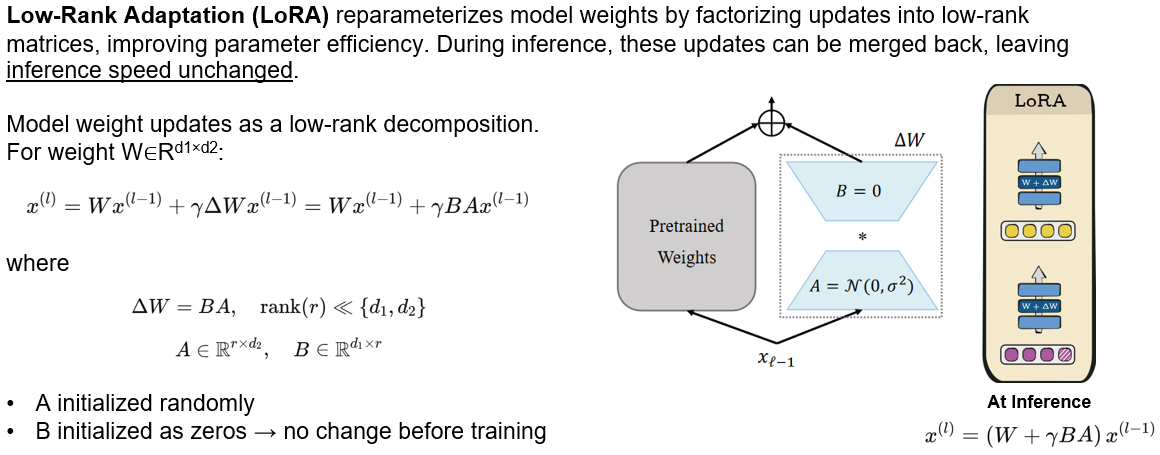


In [ ]:
!git clone https://github.com/MaxZanella/CLIP-LoRA.git loraclip

In [ ]:
from loraclip.loralib.utils import mark_only_lora_as_trainable, apply_lora, get_lora_parameters

In [ ]:
class TrainingArgs:
  """Class to hold optimizer arguments."""
  def __init__(self, lr=2e-4, n_iters=1000, batch_size=32, weight_decay=1e-2, betas=(0.9, 0.999), eta_min=1e-6):
    self.lr = lr
    self.n_iters = n_iters
    self.batch_size = batch_size
    self.weight_decay = weight_decay
    self.betas = betas
    self.eta_min = eta_min

class LoRAArgs:
  """Class to hold LoRA arguments."""
  def __init__(self, backbone='ViT-B/32', position='all', encoder='both', params=['q', 'k', 'v'], r=2, alpha=1, dropout_rate=0.25):
    self.backbone = backbone
    self.position = position
    self.encoder = encoder
    self.params = params
    self.r = r
    self.alpha = alpha
    self.dropout_rate = dropout_rate

training_args = TrainingArgs(batch_size=32)
lora_args = LoRAArgs(r=8)

#### Apply lora modules into CLIP layers

In [12]:
list_lora_layers = apply_lora(lora_args, clip_model)
mark_only_lora_as_trainable(clip_model) # Freeze all non-LoRA parameters
clip_model.to(device)

Residual Attention Block 0: ResidualAttentionBlock(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ln_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=512, out_features=2048, bias=True)
    (gelu): QuickGELU()
    (c_proj): Linear(in_features=2048, out_features=512, bias=True)
  )
  (ln_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
Residual Attention Block 1: ResidualAttentionBlock(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ln_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=512, out_features=2048, bias=True)
    (gelu): QuickGELU()
    (c_proj): Linear(in_features=2048, out_features=512, bias=True)
  )
  (ln_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
Residual Atten

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): PlainMultiheadAttentionLoRA(
            (q_proj): LinearLoRA(
              in_features=768, out_features=768, bias=True
              (dropout): Dropout(p=0.25, inplace=False)
            )
            (k_proj): LinearLoRA(
              in_features=768, out_features=768, bias=True
              (dropout): Dropout(p=0.25, inplace=False)
            )
            (v_proj): LinearLoRA(
              in_features=768, out_features=768, bias=True
              (dropout): Dropout(p=0.25, inplace=False)
            )
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequen

#### Training

In [13]:
def evaluate_lora(clip_model, loader, classnames):
  clip_model.eval()
  with torch.no_grad():
    template = 'a photo of {}.'
    texts = [template.format(classname.replace('_', ' ')) for classname in classnames]
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
      texts = clip.tokenize(texts).cuda()
      class_embeddings = clip_model.encode_text(texts)
    text_features = class_embeddings/class_embeddings.norm(dim=-1, keepdim=True)

  acc = 0.
  tot_samples = 0
  with torch.no_grad():
    for i, (images, target) in enumerate(loader):
      images, target = images.cuda(), target.cuda()
      with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        image_features = clip_model.encode_image(images)
      image_features = image_features/image_features.norm(dim=-1, keepdim=True)
      cosine_similarity = image_features @ text_features.t()
      acc += cls_acc(cosine_similarity, target) * len(cosine_similarity)
      tot_samples += len(cosine_similarity)
  acc /= tot_samples

  return acc

In [ ]:
dataset_wrapper = OxfordPetsDataset()
train_loader = CustomDataLoader(dataset_wrapper.dataset, "train", preprocess, batch_size=training_args.batch_size)
val_loader = CustomDataLoader(dataset_wrapper.dataset, "test", preprocess, batch_size=training_args.batch_size)

In [15]:
wandb.init(
    project="clip-lora-finetuning-oxfordpets",
    name=f"lora_{lora_args.encoder}_r{lora_args.r}",
    config={
        "learning_rate": training_args.lr,
        "weight_decay": training_args.weight_decay,
        "n_iters": training_args.n_iters,
        "lora_rank": lora_args.r,
        "lora_alpha": lora_args.alpha,
        "lora_encoder": lora_args.encoder,
        "batch_size": train_loader.batch_size,
    }
)

optimizer = torch.optim.AdamW(
    get_lora_parameters(clip_model),
    weight_decay=training_args.weight_decay,
    betas=training_args.betas,
    lr=training_args.lr
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, training_args.n_iters, eta_min=training_args.eta_min
)
scaler = torch.cuda.amp.GradScaler()
count_iters = 0

while count_iters < training_args.n_iters:

    # Evaluation
    if count_iters == 0 or count_iters % len(train_loader) == 0 or count_iters == training_args.n_iters - 1:
        eval_type = 'Zero-Shot' if count_iters == 0 else 'Fine-Tuning'
        print(f'{eval_type} Evaluation\n')
        clip_model.eval()
        acc_val = evaluate_lora(clip_model, val_loader, dataset_wrapper.classnames)
        print(f"**** Val accuracy: {acc_val:.2f}. ****\n")
        wandb.log({
            "val/accuracy": acc_val,
            "epoch": count_iters // len(train_loader),
            "iteration": count_iters,
        })

    # Training
    clip_model.train()
    acc_train = loss_epoch = tot_samples = 0

    for images, target in tqdm(train_loader, desc="Training LoRA"):
        images, target = images.cuda(), target.cuda()

        texts_ = [f'a photo of {c.replace("_", " ")}.' for c in dataset_wrapper.classnames]
        texts = clip.tokenize(texts_).cuda()

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            if lora_args.encoder in ['text', 'both']:
                text_features = clip_model.encode_text(texts)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            else:
                with torch.no_grad():
                    text_features = clip_model.encode_text(texts)
                    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            if lora_args.encoder in ['vision', 'both']:
                image_features = clip_model.encode_image(images)
            else:
                with torch.no_grad():
                    image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            cosine_similarity = logit_scale.detach() * image_features @ text_features.t()
            loss = F.cross_entropy(cosine_similarity, target)

        batch_acc = cls_acc(cosine_similarity, target)
        acc_train += batch_acc * target.shape[0]
        loss_epoch += loss.item() * target.shape[0]
        tot_samples += target.shape[0]
        wandb.log({
            "train/batch_loss": loss.item(),
            "train/batch_accuracy": batch_acc,
            "train/learning_rate": scheduler.get_last_lr()[0],
            "iteration": count_iters,
        })

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        count_iters += 1

        # Log epoch metrics
        if count_iters % len(train_loader) == 0 or count_iters == training_args.n_iters - 1:
            epoch_acc = acc_train / tot_samples
            epoch_loss = loss_epoch / tot_samples
            current_lr = scheduler.get_last_lr()[0]
            print(f'LR: {current_lr:.6f}, Acc: {epoch_acc:.4f}, Loss: {epoch_loss:.4f}')
            wandb.log({
                "train/epoch_accuracy": epoch_acc,
                "train/epoch_loss": epoch_loss,
                "epoch": count_iters // len(train_loader),
                "iteration": count_iters,
            })

        if count_iters == training_args.n_iters:
            break

# Finish W&B run
wandb.finish()
print("Training completed!")

wandb: Currently logged in as: federico-dasaro97 (knock-knock) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Zero-Shot Evaluation

**** Val accuracy: 10.17. ****



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [07:35<00:00,  3.96s/it]

LR: 0.000194, Acc: 11.7663, Loss: 4.4446
Fine-Tuning Evaluation



**** Val accuracy: 17.12. ****



...

 69%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                     | 79/115 [00:29<00:13,  2.67it/s]

LR: 0.000001, Acc: 95.1345, Loss: 0.1918


 69%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                     | 79/115 [00:29<00:13,  2.69it/s]


epoch,▁▂▂▃▃▄▄▅▅▅▅▆▆▇▇███
iteration,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇███
train/batch_accuracy,▂▁▁▂▂▄▄▄▆▅▆▇▆▆▆▇▆█▇▇███▇█▇███▇▇█▇█▇████▇
train/batch_loss,█▆▆▅▅▅▄▄▃▃▂▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch_accuracy,▁▃▅▇▇████
train/epoch_loss,█▅▃▂▁▁▁▁▁
train/learning_rate,██████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
val/accuracy,▁▂▄▆▇████
epoch,8
iteration,999
train/batch_accuracy,100


Training completed!
